# ODISSEO + JACCPOT FMM: First N-body Integration

This notebook runs a small ODISSEO N-body integration using the new `jaccpot` coupler workflow.

It also performs a one-step sanity check against direct summation for a small system.

In [1]:
import os
import sys
from pathlib import Path

# yggdrax uses uint64 morton constants; keep x64 on for safety
os.environ.setdefault('JAX_ENABLE_X64', '1')

def _add_repo_paths():
    candidates = []
    cwd = Path.cwd().resolve()
    candidates.append(cwd)
    candidates.append(cwd.parent)
    candidates.append(cwd / 'Odisseo')
    candidates.append(cwd.parent / 'Odisseo')
    candidates.append(Path('/Users/buck/Documents/Nexus/Projects/Odisseo'))

    checked = set()
    for od_repo in candidates:
        od_repo = od_repo.resolve()
        if od_repo in checked:
            continue
        checked.add(od_repo)
        if not od_repo.exists():
            continue

        if (od_repo / 'odisseo').exists() and str(od_repo) not in sys.path:
            sys.path.insert(0, str(od_repo))

        jac_repo = od_repo.parent / 'jaccpot'
        if jac_repo.exists() and str(jac_repo) not in sys.path:
            sys.path.insert(0, str(jac_repo))

_add_repo_paths()

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from odisseo.option_classes import (
    SimulationConfig,
    SimulationParams,
    LEAPFROG,
    DIRECT_ACC,
    
)
from odisseo.integrators import leapfrog
from odisseo.time_integration import time_integration
from odisseo.jaccpot_coupling import integrate_leapfrog_jaccpot_active

jax.config.update('jax_enable_x64', True)
print('JAX backend:', jax.default_backend())
print('using odisseo from:', Path(__import__('odisseo').__file__).resolve())


JAX backend: cpu
using odisseo from: /Users/buck/Documents/Nexus/Projects/Odisseo/odisseo/__init__.py


In [2]:
# Small random initial condition
key = jax.random.PRNGKey(42)
N = 128

k_pos, k_vel, k_mass = jax.random.split(key, 3)
positions = jax.random.uniform(k_pos, (N, 3), minval=-1.0, maxval=1.0, dtype=jnp.float32)
velocities = 0.05 * jax.random.normal(k_vel, (N, 3), dtype=jnp.float32)
masses = jax.random.uniform(k_mass, (N,), minval=0.5, maxval=1.5, dtype=jnp.float32)
state0 = jnp.stack((positions, velocities), axis=1)

params = SimulationParams(G=1.0, t_end=1.0)

cfg_fmm = SimulationConfig(
    N_particles=N,
    integrator=LEAPFROG,
    acceleration_scheme=
    num_timesteps=200,
    fixed_timestep=True,
    return_snapshots=True,
    num_snapshots=50,
    softening=1e-3,
)

cfg_direct = cfg_fmm._replace(
    N_particles=32,
    acceleration_scheme=DIRECT_ACC,
    return_snapshots=False,
    num_timesteps=1,
)

print('Configured FMM run for N=', N)


Configured FMM run for N= 128


In [3]:
# One-step sanity check: FMM vs direct acceleration update (small N)
# Make cell robust to out-of-order execution
if 'cfg_direct' not in locals():
    cfg_direct = SimulationConfig(
        N_particles=32,
        integrator=LEAPFROG,
        acceleration_scheme=DIRECT_ACC,
        num_timesteps=1,
        fixed_timestep=True,
        return_snapshots=False,
        softening=1e-3,
    )

N_check = cfg_direct.N_particles
state_check = state0[:N_check]
mass_check = masses[:N_check]
dt_check = params.t_end / cfg_direct.num_timesteps

state_next_direct = leapfrog(state_check, mass_check, dt_check, cfg_direct, params)
state_next_fmm = integrate_leapfrog_jaccpot_active(
    state_check,
    mass_check,
    cfg_direct._replace(acceleration_scheme=DIRECT_ACC),
    params,
    num_steps=1,
    dt=float(dt_check),
    refresh_every=1,
    refresh_after_position_update=True,
)

diff = jnp.max(jnp.abs(state_next_direct - state_next_fmm))
print('max |state_direct - state_fmm| after one step:', float(diff))


max |state_direct - state_fmm| after one step: 0.0001220703125


In [4]:
# Full integration with phase-2 coupler workflow
states = integrate_leapfrog_jaccpot_active(
    state0,
    masses,
    cfg_fmm,
    params,
    num_steps=cfg_fmm.num_timesteps,
    refresh_every=4,
    refresh_after_position_update=False,
    return_history=True,
)

# Downsample to mimic snapshot cadence
snap_stride = max(1, states.shape[0] // cfg_fmm.num_snapshots)
states = states[::snap_stride][: cfg_fmm.num_snapshots]
print('num snapshots:', states.shape[0])
print('state shape:', states.shape)


num snapshots: 50
state shape: (50, 128, 2, 3)


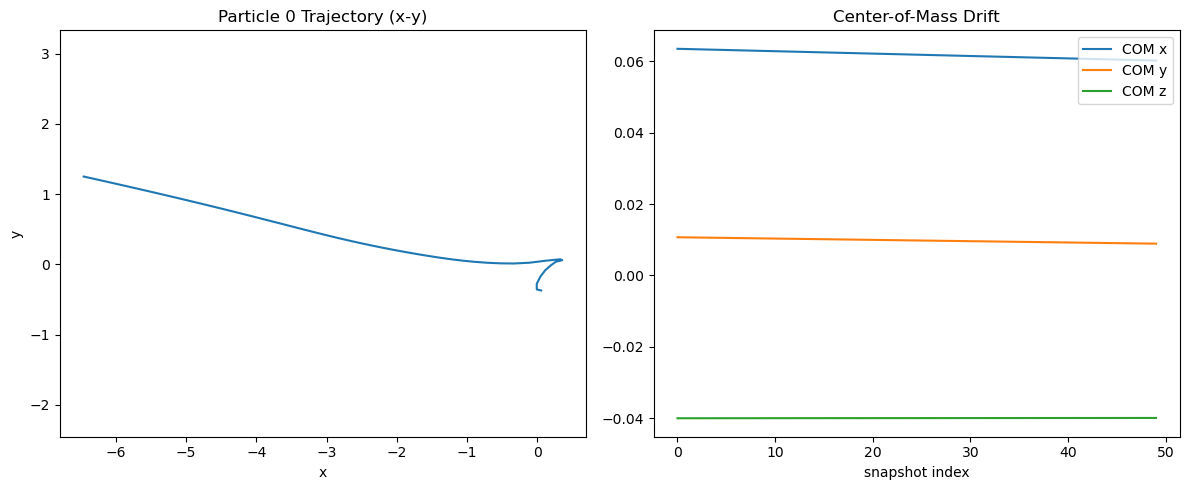

In [5]:
# Simple diagnostic plot: track COM and one particle trajectory
com = jnp.sum(states[:, :, 0, :] * masses[None, :, None], axis=1) / jnp.sum(masses)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(states[:, 0, 0, 0], states[:, 0, 0, 1], label='particle 0')
ax[0].set_title('Particle 0 Trajectory (x-y)')
ax[0].set_xlabel('x')
ax[0].set_ylabel('y')
ax[0].axis('equal')

ax[1].plot(com[:, 0], label='COM x')
ax[1].plot(com[:, 1], label='COM y')
ax[1].plot(com[:, 2], label='COM z')
ax[1].set_title('Center-of-Mass Drift')
ax[1].set_xlabel('snapshot index')
ax[1].legend()

plt.tight_layout()
plt.show()


## Runtime Benchmark: Direct vs FMM

This benchmark compares one integration step runtime (`leapfrog`) for `DIRECT_ACC` and the `jaccpot` coupler workflow.

N   direct[s]   fmm[s]   speedup(direct/fmm)
 32    0.00010   0.49066     0.000x
 64    0.00014   0.48981     0.000x
 96    0.00021   1.07748     0.000x
128    0.00025   1.05809     0.000x


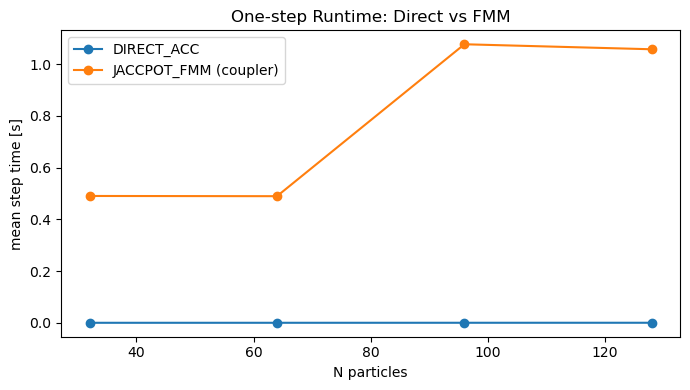

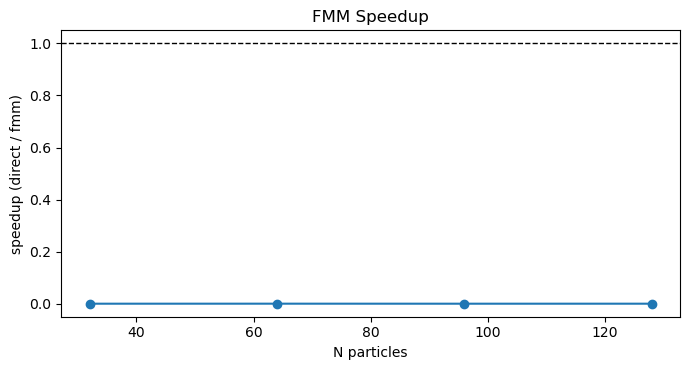

In [6]:
import time

def _time_one_step(state, mass, cfg, params, *, use_fmm=False, runs=3):
    dt = params.t_end / cfg.num_timesteps
    if use_fmm:
        _ = integrate_leapfrog_jaccpot_active(
            state, mass, cfg, params, num_steps=1, dt=float(dt), refresh_every=1, refresh_after_position_update=True
        )
    else:
        _ = leapfrog(state, mass, dt, cfg, params).block_until_ready()

    times = []
    for _ in range(runs):
        t0 = time.perf_counter()
        if use_fmm:
            out = integrate_leapfrog_jaccpot_active(
                state, mass, cfg, params, num_steps=1, dt=float(dt), refresh_every=1, refresh_after_position_update=True
            )
            _ = out.block_until_ready()
        else:
            _ = leapfrog(state, mass, dt, cfg, params).block_until_ready()
        t1 = time.perf_counter()
        times.append(t1 - t0)
    return float(jnp.mean(jnp.asarray(times)))

Ns = [32, 64, 96, 128]
bench_rows = []

for i, n in enumerate(Ns):
    key_n = jax.random.PRNGKey(100 + i)
    k1, k2, k3 = jax.random.split(key_n, 3)
    pos = jax.random.uniform(k1, (n, 3), minval=-1.0, maxval=1.0, dtype=jnp.float32)
    vel = 0.05 * jax.random.normal(k2, (n, 3), dtype=jnp.float32)
    m = jax.random.uniform(k3, (n,), minval=0.5, maxval=1.5, dtype=jnp.float32)
    s = jnp.stack((pos, vel), axis=1)

    cfg_direct_bench = SimulationConfig(
        N_particles=n,
        integrator=LEAPFROG,
        acceleration_scheme=DIRECT_ACC,
        num_timesteps=1,
        fixed_timestep=True,
        return_snapshots=False,
        softening=1e-3,
    )
    cfg_fmm_bench = cfg_direct_bench._replace(acceleration_scheme=DIRECT_ACC)

    t_direct = _time_one_step(s, m, cfg_direct_bench, params, use_fmm=False, runs=3)
    t_fmm = _time_one_step(s, m, cfg_fmm_bench, params, use_fmm=True, runs=3)

    bench_rows.append((n, t_direct, t_fmm, t_direct / t_fmm))

bench = jnp.asarray(bench_rows)
print('N   direct[s]   fmm[s]   speedup(direct/fmm)')
for n, td, tf, sp in bench_rows:
    print(f'{int(n):3d}  {td:9.5f}  {tf:8.5f}  {sp:8.3f}x')

plt.figure(figsize=(7, 4))
plt.plot(bench[:, 0], bench[:, 1], 'o-', label='DIRECT_ACC')
plt.plot(bench[:, 0], bench[:, 2], 'o-', label='jaccpot coupler')
plt.xlabel('N particles')
plt.ylabel('mean step time [s]')
plt.title('One-step Runtime: Direct vs FMM')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 3.8))
plt.plot(bench[:, 0], bench[:, 3], 'o-')
plt.axhline(1.0, color='k', linestyle='--', linewidth=1)
plt.xlabel('N particles')
plt.ylabel('speedup (direct / fmm)')
plt.title('FMM Speedup')
plt.tight_layout()
plt.show()


## End-to-End Runtime Benchmark (Multi-step)

This benchmark compares total integration wall-time for a short multi-step run with snapshots disabled.

In [ ]:
def _time_full_integration(state, mass, cfg, params, *, use_fmm=False, runs=2):
    if use_fmm:
        _ = integrate_leapfrog_jaccpot_active(
            state,
            mass,
            cfg,
            params,
            num_steps=cfg.num_timesteps,
            refresh_every=4,
            refresh_after_position_update=False,
            return_history=False,
        )
    else:
        out = time_integration(state, mass, cfg, params)
        _ = jax.tree_util.tree_map(lambda x: x.block_until_ready() if hasattr(x, 'block_until_ready') else x, out)

    times = []
    for _ in range(runs):
        t0 = time.perf_counter()
        if use_fmm:
            out = integrate_leapfrog_jaccpot_active(
                state,
                mass,
                cfg,
                params,
                num_steps=cfg.num_timesteps,
                refresh_every=4,
                refresh_after_position_update=False,
                return_history=False,
            )
            _ = out.block_until_ready()
        else:
            out = time_integration(state, mass, cfg, params)
            _ = jax.tree_util.tree_map(lambda x: x.block_until_ready() if hasattr(x, 'block_until_ready') else x, out)
        t1 = time.perf_counter()
        times.append(t1 - t0)
    return float(jnp.mean(jnp.asarray(times)))

Ns_full = [64, 96, 128]
bench_full_rows = []

for i, n in enumerate(Ns_full):
    key_n = jax.random.PRNGKey(500 + i)
    k1, k2, k3 = jax.random.split(key_n, 3)
    pos = jax.random.uniform(k1, (n, 3), minval=-1.0, maxval=1.0, dtype=jnp.float32)
    vel = 0.05 * jax.random.normal(k2, (n, 3), dtype=jnp.float32)
    m = jax.random.uniform(k3, (n,), minval=0.5, maxval=1.5, dtype=jnp.float32)
    s = jnp.stack((pos, vel), axis=1)

    cfg_direct_full = SimulationConfig(
        N_particles=n,
        integrator=LEAPFROG,
        acceleration_scheme=DIRECT_ACC,
        num_timesteps=50,
        fixed_timestep=True,
        return_snapshots=False,
        softening=1e-3,
    )
    cfg_fmm_full = cfg_direct_full._replace(acceleration_scheme=DIRECT_ACC)

    t_direct_full = _time_full_integration(s, m, cfg_direct_full, params, use_fmm=False, runs=2)
    t_fmm_full = _time_full_integration(s, m, cfg_fmm_full, params, use_fmm=True, runs=2)

    bench_full_rows.append((n, t_direct_full, t_fmm_full, t_direct_full / t_fmm_full))

bench_full = jnp.asarray(bench_full_rows)
print('N   direct_full[s]   fmm_full[s]   speedup(direct/fmm)')
for n, td, tf, sp in bench_full_rows:
    print(f'{int(n):3d}  {td:13.5f}  {tf:11.5f}  {sp:8.3f}x')

plt.figure(figsize=(7, 4))
plt.plot(bench_full[:, 0], bench_full[:, 1], 'o-', label='DIRECT_ACC (full run)')
plt.plot(bench_full[:, 0], bench_full[:, 2], 'o-', label='jaccpot coupler full run')
plt.xlabel('N particles')
plt.ylabel('mean integration time [s]')
plt.title('End-to-End Runtime (50 Leapfrog Steps)')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 3.8))
plt.plot(bench_full[:, 0], bench_full[:, 3], 'o-')
plt.axhline(1.0, color='k', linestyle='--', linewidth=1)
plt.xlabel('N particles')
plt.ylabel('speedup (direct / fmm)')
plt.title('End-to-End FMM Speedup')
plt.tight_layout()
plt.show()


## Notes
- This example uses the ODISSEO + `jaccpot` coupler workflow for self-gravity.
- External potentials remain additive in ODISSEO exactly as before.
- For active-particle substeps with cached source tree reuse, the next iteration is to wire ODISSEO integrator loops to `jaccpot.OdisseoFMMCoupler`.